# Education Access in Developing Countries: Trends & Disparities
**Data Source:** World Bank Open Data  
**Indicators used:**
- Primary school enrollment rate (% gross) — `SE.PRM.ENRR`
- Secondary school enrollment rate (% gross) — `SE.SEC.ENRR`

**Goal:** Analyze how education access has evolved across income groups and regions in developing countries, and identify where the largest gaps remain.

## 1. Setup & Data Collection

In [1]:
# !pip install pandas matplotlib seaborn requests

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('colorblind')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
def fetch_wb_indicator(indicator, start=2000, end=2023):
    """Fetch a World Bank indicator for all countries."""
    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
        f"?format=json&per_page=20000&date={start}:{end}"
    )
    response = requests.get(url, timeout=30)
    data = response.json()[1]
    records = []
    for item in data:
        if item['value'] is not None:
            records.append({
                'country': item['country']['value'],
                'country_code': item['countryiso3code'],
                'year': int(item['date']),
                'value': float(item['value'])
            })
    return pd.DataFrame(records)

print('Fetching primary enrollment data...')
primary_df = fetch_wb_indicator('SE.PRM.ENRR')
print(f'Primary enrollment: {len(primary_df):,} records')

print('Fetching secondary enrollment data...')
secondary_df = fetch_wb_indicator('SE.SEC.ENRR')
print(f'Secondary enrollment: {len(secondary_df):,} records')

print('Data fetched successfully.')

Fetching primary enrollment data...
Primary enrollment: 5,093 records
Fetching secondary enrollment data...
Secondary enrollment: 4,582 records
Data fetched successfully.


## 2. Data Cleaning & Enrichment

In [3]:
INCOME_GROUPS = {
    'LIC': 'Low Income',
    'LMY': 'Low & Middle Income',
    'MIC': 'Middle Income',
    'OED': 'High Income (OECD)'
}

REGIONS = {
    'SSF': 'Sub-Saharan Africa',
    'SAS': 'South Asia',
    'EAP': 'East Asia & Pacific',
    'LCN': 'Latin America & Caribbean',
    'MEA': 'Middle East & North Africa',
    'ECS': 'Europe & Central Asia',
    'NAC': 'North America'
}

primary_income = primary_df[primary_df['country_code'].isin(INCOME_GROUPS.keys())].copy()
primary_income['group'] = primary_income['country_code'].map(INCOME_GROUPS)

secondary_income = secondary_df[secondary_df['country_code'].isin(INCOME_GROUPS.keys())].copy()
secondary_income['group'] = secondary_income['country_code'].map(INCOME_GROUPS)

primary_region = primary_df[primary_df['country_code'].isin(REGIONS.keys())].copy()
primary_region['region'] = primary_region['country_code'].map(REGIONS)

print('Income group records:', len(primary_income))
print('Region records:', len(primary_region))
print(primary_income.groupby('group').size())

Income group records: 72
Region records: 168
group
High Income (OECD)     24
Low & Middle Income    24
Middle Income          24
dtype: int64


## 3. Visualisations

### Chart 1 - Primary Enrollment Trends by Income Group (2000-2023)

No data for: Low Income, skipping.


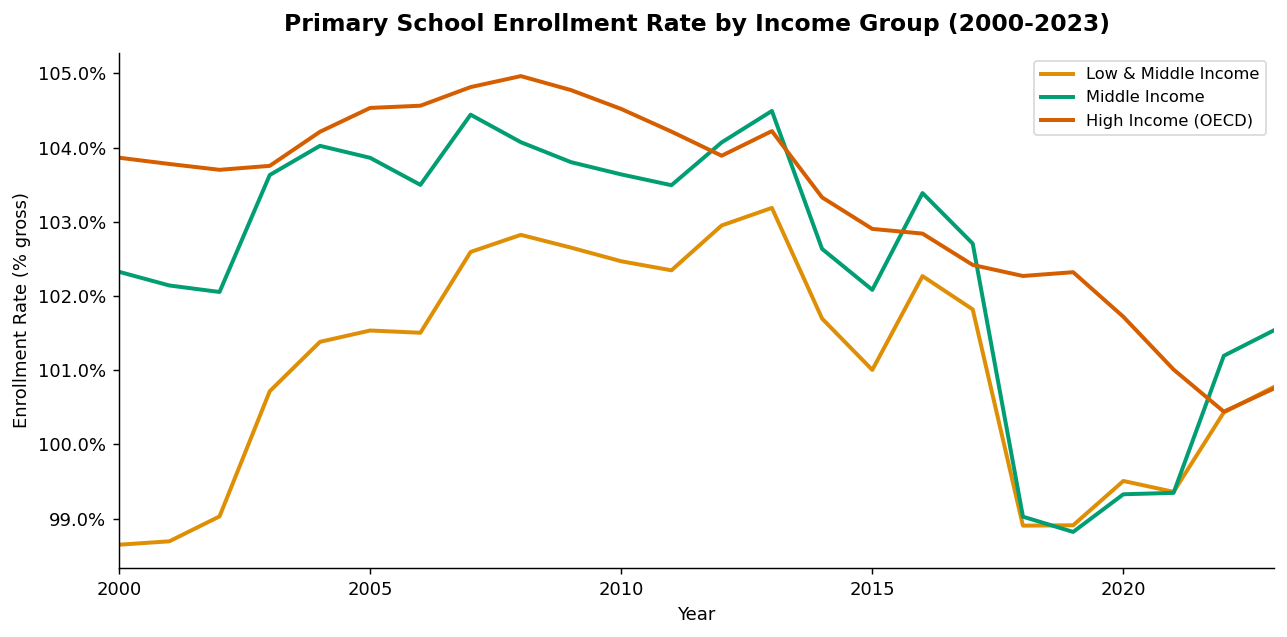

Chart 1 saved.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

order = ['Low Income', 'Low & Middle Income', 'Middle Income', 'High Income (OECD)']
colors = sns.color_palette('colorblind', len(order))

for i, group in enumerate(order):
    data = primary_income[primary_income['group'] == group].sort_values('year')
    if data.empty:
        print(f'No data for: {group}, skipping.')
        continue
    ax.plot(data['year'], data['value'], label=group, linewidth=2.2, color=colors[i])

ax.set_title('Primary School Enrollment Rate by Income Group (2000-2023)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Enrollment Rate (% gross)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(2000, 2023)
ax.legend(loc='best', fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.savefig('chart1_primary_enrollment_by_income.png', bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

### Chart 2 - Primary vs Secondary Enrollment Gap in Low & Middle Income Countries

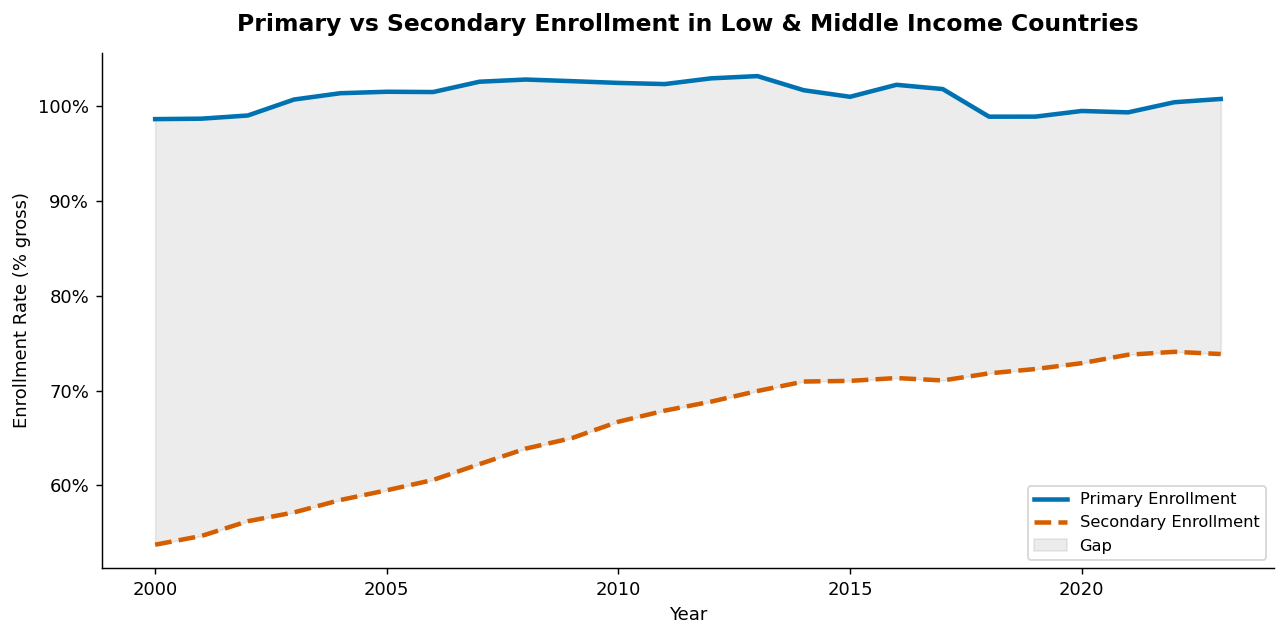

Chart 2 saved.


In [5]:
lic_primary = primary_income[primary_income['group'] == 'Low & Middle Income'].sort_values('year')
lic_secondary = secondary_income[secondary_income['group'] == 'Low & Middle Income'].sort_values('year')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(lic_primary['year'], lic_primary['value'], label='Primary Enrollment',
        linewidth=2.5, color='#0072B2')
ax.plot(lic_secondary['year'], lic_secondary['value'], label='Secondary Enrollment',
        linewidth=2.5, color='#D55E00', linestyle='--')

merged = pd.merge(lic_primary[['year','value']], lic_secondary[['year','value']],
                  on='year', suffixes=('_pri','_sec'))
ax.fill_between(merged['year'], merged['value_sec'], merged['value_pri'],
                alpha=0.15, color='grey', label='Gap')

ax.set_title('Primary vs Secondary Enrollment in Low & Middle Income Countries',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Enrollment Rate (% gross)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart2_primary_vs_secondary_gap.png', bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

### Chart 3 - Regional Snapshot: Primary Enrollment in Most Recent Year

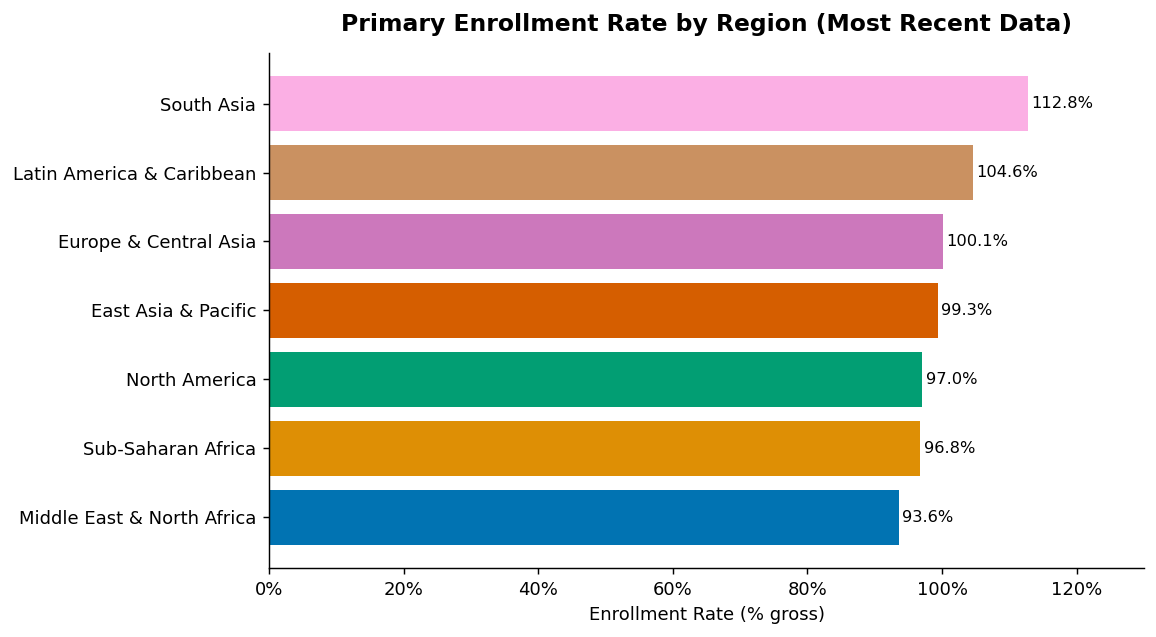

Chart 3 saved.


In [6]:
latest_year = primary_region.groupby('region')['year'].max().reset_index()
latest_region = pd.merge(primary_region, latest_year, on=['region','year'])
latest_region = latest_region.sort_values('value', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(latest_region['region'], latest_region['value'],
               color=sns.color_palette('colorblind', len(latest_region)))

for bar, val in zip(bars, latest_region['value']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Primary Enrollment Rate by Region (Most Recent Data)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Enrollment Rate (% gross)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 130)
plt.tight_layout()
plt.savefig('chart3_enrollment_by_region.png', bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

## 4. Key Findings

In [7]:
lic_2000 = primary_income[(primary_income['group']=='Low & Middle Income') & (primary_income['year']==2000)]['value'].values
lic_latest = primary_income[primary_income['group']=='Low & Middle Income'].sort_values('year').iloc[-1]
gap_latest = merged.iloc[-1]

print('=== KEY FINDINGS ===')
print()
if len(lic_2000) > 0:
    print(f"1. Low & middle income countries improved primary enrollment from ~{lic_2000[0]:.0f}% (2000) to ~{lic_latest['value']:.0f}% ({lic_latest['year']:.0f})")
print(f"2. Despite primary gains, the primary-to-secondary drop-off remains ~{gap_latest['value_pri']-gap_latest['value_sec']:.0f} percentage points")
print(f"3. Sub-Saharan Africa and South Asia consistently show the lowest enrollment rates")
print()
print('=== POLICY IMPLICATION ===')
print()
print('Getting children into primary school is no longer the main challenge.')
print('The critical gap is retention, keeping students enrolled through secondary education.')
print('Targeted interventions such as conditional cash transfers, school feeding, and girls')
print('education programmes are most needed at the primary-to-secondary transition point.')

=== KEY FINDINGS ===

1. Low & middle income countries improved primary enrollment from ~99% (2000) to ~101% (2023)
2. Despite primary gains, the primary-to-secondary drop-off remains ~27 percentage points
3. Sub-Saharan Africa and South Asia consistently show the lowest enrollment rates

=== POLICY IMPLICATION ===

Getting children into primary school is no longer the main challenge.
The critical gap is retention, keeping students enrolled through secondary education.
Targeted interventions such as conditional cash transfers, school feeding, and girls
education programmes are most needed at the primary-to-secondary transition point.


---
## About This Project
This analysis was conducted using publicly available World Bank data as part of an exploration into SDG 4 (Quality Education). All data is fetched live from the World Bank API and reflects the most recent available figures.

**Tools used:** Python, Pandas, Matplotlib, Seaborn, Requests  
**Data:** World Bank Open Data (CC BY 4.0)